# ANFIS 6-Variable Model — Official Dissertation Scheme (CodeWorkout S19 Dataset)

**Variable scheme (unit of analysis: Student-Problem pair, not per-student aggregate):**

| Type | Variable | Definition | Source |
|---|---|---|---|
| X1 | `early_error_rate` | Proportion of compile failures in the first 2 compile attempts | `MainTable.csv` |
| X2 | `early_time_gap_sec` (log1p) | Time gap between compile #1 and #2 | `MainTable.csv` |
| X3 | `early_error_repeat` | Biner: kedua compile pertama sama-sama gagal | `MainTable.csv` |
| X4 | `code_len_first` | Code length at the first compile | `CodeStates.csv` |
| X5 | `code_len_delta` | Difference length kode compile 1 vs 2 | `CodeStates.csv` |
| X6 | `code_similarity_1_2` | Text similarity of compile 1 vs 2 code | `CodeStates.csv` |
| **Y** | **`Label`** | Binary — 1 = "efficient success" (completed & attempts ≤ P75 on the same problem), 0 = needs scaffolding | `early.csv` + `late.csv` (kolom bawaan dataset) |

This is a **binary classification** scheme (not regression like the earlier 3-variable demo). This notebook:
1. Accepts an uploaded CodeWorkout dataset archive (**ZIP or RAR**).
2. Computes X1–X3 from `Compile` event logs in `MainTable.csv` (first 2 attempts per Student-Problem pair).
3. Computes X4–X6 from the source code (`CodeStates.csv`) at the matching 1st and 2nd compile.
4. Merges with the dataset's built-in `Label` (from `early.csv`+`late.csv`).
5. Trains a first-order Sugeno ANFIS (2 MF/variable → **2⁶ = 64 rules**), evaluated with AUC, accuracy, precision/recall/F1 (not RMSE/R² — karena target biner).
6. Saves all results to downloadable files.


## Section 1: Installation & Library Imports

In [3]:
import os, io, json, shutil, zipfile, itertools, subprocess
from pathlib import Path
from difflib import SequenceMatcher
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
)
try:
    import rarfile
    for _kandidat in ["unrar", "unrar-free"]:
        if shutil.which(_kandidat):
            rarfile.UNRAR_TOOL = _kandidat
            break
except ImportError:
    pass
try:
    from google.colab import files
except ImportError:
    pass
np.random.seed(42)

!pip install -q scikit-learn pandas numpy matplotlib rarfile
!apt-get install -y -qq unrar > /dev/null 2>&1 || apt-get install -y -qq unrar-free > /dev/null 2>&1

print("Library siap (mendukung ekstraksi ZIP maupun RAR).")

Library siap (mendukung ekstraksi ZIP maupun RAR).


## Section 2: Upload Dataset File (ZIP or RAR)

Run the cell below, then select the file arsip dataset CodeWorkout of komputer
you — **either `.zip` or `.rar` format is fine**. The archive must contain `MainTable.csv`,
`CodeStates.csv`, `early.csv`, and `late.csv` (the 6-variable scheme needs all four,
unlike the 3-variable demo which only needs `early.csv`/`late.csv`).


In [4]:
import os, io, json, shutil, zipfile, itertools, subprocess
from pathlib import Path
from difflib import SequenceMatcher
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
)
try:
    import rarfile
    for _kandidat in ["unrar", "unrar-free"]:
        if shutil.which(_kandidat):
            rarfile.UNRAR_TOOL = _kandidat
            break
except ImportError:
    pass
try:
    from google.colab import files
except ImportError:
    pass
np.random.seed(42)

from google.colab import files

print("Please select the CodeWorkout dataset ZIP or RAR file to upload...")
uploaded = files.upload()

nama_file = list(uploaded.keys())[0]
ekstensi = Path(nama_file).suffix.lower()
print(f"\nFile terupload: {nama_file} ({len(uploaded[nama_file])/1024:.1f} KB, format: {ekstensi})")

EXTRACT_DIR = "/content/dataset_extracted"
os.makedirs(EXTRACT_DIR, exist_ok=True)

if ekstensi == ".zip":
    with zipfile.ZipFile(io.BytesIO(uploaded[nama_file]), "r") as z:
        z.extractall(EXTRACT_DIR)
elif ekstensi == ".rar":
    tmp_rar_path = f"/content/_upload_tmp{ekstensi}"
    with open(tmp_rar_path, "wb") as f:
        f.write(uploaded[nama_file])
    with rarfile.RarFile(tmp_rar_path) as rf:
        rf.extractall(EXTRACT_DIR)
    os.remove(tmp_rar_path)
else:
    raise ValueError(f"File format '{ekstensi}' is not supported. Please upload a .zip or .rar file.")

print(f"\nEkstraksi selesai ke: {EXTRACT_DIR}")
print("\nDaftar file hasil ekstraksi:")
for p in sorted(Path(EXTRACT_DIR).rglob("*")):
    if p.is_file():
        print(" -", p.relative_to(EXTRACT_DIR))

Please select the CodeWorkout dataset ZIP or RAR file to upload...


Saving S19_All_Release_2_10_22.zip to S19_All_Release_2_10_22.zip

File terupload: S19_All_Release_2_10_22.zip (7741.5 KB, format: .zip)

Ekstraksi selesai ke: /content/dataset_extracted

Daftar file hasil ekstraksi:
 - Data/CodeStates/CodeStates.csv
 - Data/DatasetMetadata.csv
 - Data/LinkTables/Subject.csv
 - Data/MainTable.csv
 - early.csv
 - late.csv


## Section 3: Automatically Locate Source Files

Searching for `MainTable.csv`, `CodeStates.csv`, `early.csv`, `late.csv` di manapun
its location within the extracted files (no need to know the exact folder structure).


In [6]:
import os, io, json, shutil, zipfile, itertools, subprocess
from pathlib import Path
from difflib import SequenceMatcher
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
)
try:
    import rarfile
    for _kandidat in ["unrar", "unrar-free"]:
        if shutil.which(_kandidat):
            rarfile.UNRAR_TOOL = _kandidat
            break
except ImportError:
    pass
try:
    from google.colab import files
except ImportError:
    pass
np.random.seed(42)

def cari_file(nama_file, root_dir):
    hasil = list(Path(root_dir).rglob(nama_file))
    if not hasil:
        raise FileNotFoundError(f"File '{nama_file}' was not found inside the archive.")
    if len(hasil) > 1:
        print(f"Warning: found more than one '{nama_file}', using the first one: {hasil[0]}")
    return hasil[0]

path_main = cari_file("MainTable.csv", EXTRACT_DIR)
path_codestates = cari_file("CodeStates.csv", EXTRACT_DIR)
path_early = cari_file("early.csv", EXTRACT_DIR)
path_late = cari_file("late.csv", EXTRACT_DIR)

print("MainTable.csv    :", path_main)
print("CodeStates.csv   :", path_codestates)
print("early.csv        :", path_early)
print("late.csv         :", path_late)

main = pd.read_csv(path_main)
codestates = pd.read_csv(path_codestates)
early = pd.read_csv(path_early)
late = pd.read_csv(path_late)

print(f"\nMainTable.csv  -> {main.shape[0]} baris, {main.shape[1]} kolom")
print(f"CodeStates.csv -> {codestates.shape[0]} baris, {codestates.shape[1]} kolom")
print(f"early.csv      -> {early.shape[0]} baris, {early.shape[1]} kolom")
print(f"late.csv       -> {late.shape[0]} baris, {late.shape[1]} kolom")
display(main.head(3))

MainTable.csv    : /content/dataset_extracted/Data/MainTable.csv
CodeStates.csv   : /content/dataset_extracted/Data/CodeStates/CodeStates.csv
early.csv        : /content/dataset_extracted/early.csv
late.csv         : /content/dataset_extracted/late.csv

MainTable.csv  -> 201570 baris, 19 kolom
CodeStates.csv -> 69627 baris, 2 kolom
early.csv      -> 9106 baris, 6 kolom
late.csv       -> 5722 baris, 6 kolom


,Order,SubjectID,ToolInstances,ServerTimestamp,ServerTimezone,CourseID,CourseSectionID,AssignmentID,ProblemID,CodeStateID,IsEventOrderingConsistent,EventType,Score,Compile.Result,CompileMessageType,CompileMessageData,EventID,ParentEventID,SourceLocation
0,119630,00c54f9462673d4c09d2a88121860841,Java 8; CodeWorkout,2019-02-24T05:13:03,UTC,CS 1,1,439.0,1,efdf3fae54cdc0a09fb81fcfa365c5f843e837b0,True,Run.Program,1.0,NaN,NaN,NaN,1-69176,NaN,NaN
1,119631,00c54f9462673d4c09d2a88121860841,Java 8; CodeWorkout,2019-02-24T05:13:03,UTC,CS 1,1,439.0,1,efdf3fae54cdc0a09fb81fcfa365c5f843e837b0,True,Compile,NaN,Success,NaN,NaN,1-69177,1-69176,NaN
2,134330,00c54f9462673d4c09d2a88121860841,Java 8; CodeWorkout,2019-02-24T05:13:33,0,CS 1,1,439.0,3,79b2bcc8f502e1f7d2d4e83d1894964684c89b85,True,Run.Program,1.0,NaN,NaN,NaN,3-68089,NaN,NaN


## Section 4: Compute X1–X3 (from `MainTable.csv`, Compile events)

For each pair (`SubjectID`, `AssignmentID`, `ProblemID`): ambil 2 event
`Compile` pertama berdasarkan urutan waktu (`ServerTimestamp`), lalu hitung
X1 (proporsi error), X2 (jeda waktu, `log1p`), X3 (biner keduanya gagal).
Pairs with fewer than 2 Compile events **cannot be used** (X1–X3 are undefined).


In [7]:
import os, io, json, shutil, zipfile, itertools, subprocess
from pathlib import Path
from difflib import SequenceMatcher
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
)
try:
    import rarfile
    for _kandidat in ["unrar", "unrar-free"]:
        if shutil.which(_kandidat):
            rarfile.UNRAR_TOOL = _kandidat
            break
except ImportError:
    pass
try:
    from google.colab import files
except ImportError:
    pass
np.random.seed(42)

pairs = pd.concat([early, late], ignore_index=True)
print(f"Total Student-Problem pair (early+late): {len(pairs)}")

compile_df = main[main["EventType"] == "Compile"].copy()
compile_df["ServerTimestamp"] = pd.to_datetime(compile_df["ServerTimestamp"])

group_cols = ["SubjectID", "AssignmentID", "ProblemID"]
compile_df = compile_df.sort_values(group_cols + ["ServerTimestamp"])
compile_df["urutan_compile"] = compile_df.groupby(group_cols).cumcount() + 1

first_two = compile_df[compile_df["urutan_compile"] <= 2].copy()
jumlah_compile = first_two.groupby(group_cols)["urutan_compile"].max().reset_index()
jumlah_compile.columns = group_cols + ["n_compile_early"]

c1 = first_two[first_two["urutan_compile"] == 1].set_index(group_cols)
c2 = first_two[first_two["urutan_compile"] == 2].set_index(group_cols)

hasil = jumlah_compile.set_index(group_cols).copy()
hasil = hasil[hasil["n_compile_early"] >= 2]
print(f"Pairs with >=2 Compile events (X1-X6 computable): {len(hasil)}")

err1 = (c1.loc[hasil.index, "Compile.Result"] == "Error").astype(int)
err2 = (c2.loc[hasil.index, "Compile.Result"] == "Error").astype(int)
hasil["X1_early_error_rate"] = (err1 + err2) / 2.0

t1 = c1.loc[hasil.index, "ServerTimestamp"]
t2 = c2.loc[hasil.index, "ServerTimestamp"]
gap_sec = np.clip((t2.values - t1.values) / np.timedelta64(1, "s"), 0, None)
hasil["X2_early_time_gap_sec"] = np.log1p(gap_sec)

hasil["X3_early_error_repeat"] = ((err1 == 1) & (err2 == 1)).astype(int)

print("\nContoh hasil X1-X3:")
display(hasil[["X1_early_error_rate", "X2_early_time_gap_sec", "X3_early_error_repeat"]].head())

Total Student-Problem pair (early+late): 14828
Pairs with >=2 Compile events (X1-X6 computable): 9866

Contoh hasil X1-X3:


X1_early_error_rate  \
SubjectID                        AssignmentID ProblemID                        
00c54f9462673d4c09d2a88121860841 439.0        5                          0.0   
                                              12                         0.0   
                                              13                         1.0   
                                              232                        1.0   
                                 487.0        101                        0.5   

                                                         X2_early_time_gap_sec  \
SubjectID                        AssignmentID ProblemID                          
00c54f9462673d4c09d2a88121860841 439.0        5                       3.637586   
                                              12                      3.465736   
                                              13                      4.753590   
                                              232                     2.484907   
                                 487.0        101                     5.556828   

                                                         X3_early_error_repeat  
SubjectID                        AssignmentID ProblemID                         
00c54f9462673d4c09d2a88121860841 439.0        5                              0  
                                              12                             0  
                                              13                             1  
                                              232                            1  
                                 487.0        101                            0

## Section 5: Compute X4–X6 (from `CodeStates.csv`, source code of compile 1 & 2)

X4 = length kode compile pertama, X5 = selisih length kode compile 2 − compile 1,
X6 = rasio kemiripan teks kode compile 1 vs 2 (`SequenceMatcher`). Proses ini
takes a few seconds since it compares the code text of thousands of pairs.


In [8]:
import os, io, json, shutil, zipfile, itertools, subprocess
from pathlib import Path
from difflib import SequenceMatcher
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
)
try:
    import rarfile
    for _kandidat in ["unrar", "unrar-free"]:
        if shutil.which(_kandidat):
            rarfile.UNRAR_TOOL = _kandidat
            break
except ImportError:
    pass
try:
    from google.colab import files
except ImportError:
    pass
np.random.seed(42)

code_map = codestates.set_index("CodeStateID")["Code"].to_dict()

cs1 = c1.loc[hasil.index, "CodeStateID"].map(code_map).fillna("")
cs2 = c2.loc[hasil.index, "CodeStateID"].map(code_map).fillna("")

hasil["X4_code_len_first"] = cs1.str.len().values
hasil["X5_code_len_delta"] = (cs2.str.len().values - cs1.str.len().values)

print("Computing X6 (code similarity) ...")
hasil["X6_code_similarity_1_2"] = [
    SequenceMatcher(None, a, b).ratio() for a, b in zip(cs1.values, cs2.values)
]

hasil = hasil.reset_index()
print("Selesai. Contoh X4-X6:")
display(hasil[["X4_code_len_first", "X5_code_len_delta", "X6_code_similarity_1_2"]].head())

Computing X6 (code similarity) ...
Selesai. Contoh X4-X6:


,X4_code_len_first,X5_code_len_delta,X6_code_similarity_1_2
0,219,2,0.636364
1,199,0,0.939698
2,526,-1,0.490961
3,307,3,0.956240
4,220,-3,0.910755


## Section 6: Merge with `Label` and Save Final Dataset


In [9]:
import os, io, json, shutil, zipfile, itertools, subprocess
from pathlib import Path
from difflib import SequenceMatcher
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
)
try:
    import rarfile
    for _kandidat in ["unrar", "unrar-free"]:
        if shutil.which(_kandidat):
            rarfile.UNRAR_TOOL = _kandidat
            break
except ImportError:
    pass
try:
    from google.colab import files
except ImportError:
    pass
np.random.seed(42)

dataset = pairs.merge(hasil, on=group_cols, how="inner")
dataset["Label"] = dataset["Label"].astype(int)

print(f"Dataset final (siap ANFIS): N = {len(dataset)} Student-Problem pair")
print(f"Distribusi Label -- 1=berhasil efisien, 0=butuh scaffolding:")
print(dataset["Label"].value_counts())
print(f"Proporsi Label=1 : {dataset['Label'].mean()*100:.1f}%")

FEATURES = [
    "X1_early_error_rate", "X2_early_time_gap_sec", "X3_early_error_repeat",
    "X4_code_len_first", "X5_code_len_delta", "X6_code_similarity_1_2",
]
kolom_final = group_cols + FEATURES + ["Attempts", "CorrectEventually", "Label"]
dataset = dataset[kolom_final]
dataset.to_csv("dataset_anfis_6var.csv", index=False)
print("\nSaved: dataset_anfis_6var.csv")
display(dataset.describe())

Dataset final (siap ANFIS): N = 9153 Student-Problem pair
Distribusi Label -- 1=berhasil efisien, 0=butuh scaffolding:
Label
1    5407
0    3746
Name: count, dtype: int64
Proporsi Label=1 : 59.1%

Saved: dataset_anfis_6var.csv


,AssignmentID,ProblemID,X1_early_error_rate,X2_early_time_gap_sec,X3_early_error_repeat,X4_code_len_first,X5_code_len_delta,X6_code_similarity_1_2,Attempts,Label
count,9153.000000,9153.00000,9153.000000,9153.000000,9153.000000,9153.000000,9153.000000,9153.000000,9153.000000,9153.000000
mean,481.758986,72.92975,0.574566,3.679495,0.389708,285.973670,19.641429,0.891502,6.178084,0.590735
std,22.707682,65.63750,0.389907,1.484132,0.487711,139.478114,71.466703,0.186120,6.763662,0.491725
min,439.000000,1.00000,0.000000,0.000000,0.000000,42.000000,-788.000000,0.066318,1.000000,0.000000
25%,487.000000,31.00000,0.500000,2.772589,0.000000,198.000000,0.000000,0.892655,2.000000,0.000000
50%,492.000000,46.00000,0.500000,3.332205,0.000000,260.000000,2.000000,0.979742,4.000000,1.000000
75%,494.000000,102.00000,1.000000,4.234107,1.000000,356.000000,17.000000,0.995595,7.000000,1.000000
max,502.000000,236.00000,1.000000,12.865433,1.000000,1373.000000,1187.000000,1.000000,93.000000,1.000000


## Section 7: Label Formation Audit (P75 Definition Verification)

In [10]:
# ============================================================
# AUDIT: verifikasi apakah kolom Label bawaan dataset (early.csv+
# late.csv) benar-benar konsisten with the claimed P75 definition
# di jurnal (Label=1 jika tuntas DAN Attempts <= P75 per ProblemID)
# ============================================================
kolom_attempts = "Attempts" if "Attempts" in pairs.columns else None
kolom_correct = "CorrectEventually" if "CorrectEventually" in pairs.columns else None

print("Columns available in pairs:", list(pairs.columns))
print(f"Attempts column found: {kolom_attempts is not None}")
print(f"CorrectEventually column found: {kolom_correct is not None}")

if kolom_attempts and kolom_correct and "Label" in pairs.columns:
    # Hitung P75 jumlah attempts per ProblemID (sesuai definisi Tabel 3 jurnal)
    p75_per_problem = pairs.groupby("ProblemID")[kolom_attempts].transform(
        lambda x: x.quantile(0.75)
    )
    label_hitung_ulang = (
        (pairs[kolom_correct] == True) & (pairs[kolom_attempts] <= p75_per_problem)
    ).astype(int)

    label_asli = pairs["Label"].astype(int)
    jumlah_cocok = (label_hitung_ulang == label_asli).sum()
    persen_cocok = jumlah_cocok / len(pairs) * 100

    print(f"\nNumber of rows matching the P75 definition: {jumlah_cocok}/{len(pairs)} ({persen_cocok:.2f}%)")
    if persen_cocok >= 99.0:
        print("=> Label bawaan dataset VERIFIED consistent with the P75 definition.")
    else:
        print("=> WARNING: Dataset's built-in Label does NOT fully match dengan")
        print("   the claimed P75 definition. The original dataset Label definition needs")
        print("   re-checking, or Label should be recomputed manually of sini.")
else:
    print("\nWARNING: Attempts/CorrectEventually/Label columns are incomplete")
    print("di 'pairs' -- audit cannot be run. Check the original column names")
    print("in your early.csv/late.csv.")


Columns available in pairs: ['SubjectID', 'AssignmentID', 'ProblemID', 'Attempts', 'CorrectEventually', 'Label']
Attempts column found: True
CorrectEventually column found: True

Number of rows matching the P75 definition: 14828/14828 (100.00%)
=> Label bawaan dataset VERIFIED consistent with the P75 definition.


## Section 8: Discarded Data Characteristics Analysis (Selection Bias Check)

In [11]:
from google.colab import files

# ============================================================
# ANALISIS DATA YANG TERBUANG: karakteristik pasangan Student-
# problems with <2 compilation attempts (eliminated from 14,828
# into 9,153 final rows), to test for potential selection bias
# toward two extreme groups: highly proficient students (immediately correct
# without revision) and students who gave up (did not try again).
# ============================================================

# Identify rows in 'pairs' (N=14,828) that are NOT included in the
# final dataset (dataset, N=9,153) -- this is the discarded data
pairs_semua = pairs.copy()
index_terpakai = dataset.index
pairs_terbuang = pairs_semua.loc[~pairs_semua.index.isin(index_terpakai)].copy()
pairs_terpakai = pairs_semua.loc[pairs_semua.index.isin(index_terpakai)].copy()

print(f"Initial row total (pairs)      : {len(pairs_semua)}")
print(f"Rows used (final dataset): {len(pairs_terpakai)}")
print(f"Rows discarded (<2 kompilasi) : {len(pairs_terbuang)} "
      f"({len(pairs_terbuang)/len(pairs_semua)*100:.1f}%)")

# ============================================================
# Karakteristik data terbuang: status penyelesaian & jumlah percobaan
# ============================================================
print("\n=== DISCARDED DATA CHARACTERISTICS ===")
print(f"CorrectEventually distribution in DISCARDED data:")
print(pairs_terbuang["CorrectEventually"].value_counts(normalize=True).mul(100).round(1))

print(f"\nAttempts distribution in DISCARDED data:")
print(pairs_terbuang["Attempts"].value_counts().sort_index().head(10))

print(f"\nCorrectEventually distribution in USED (final) data:")
print(pairs_terpakai["CorrectEventually"].value_counts(normalize=True).mul(100).round(1))

# ============================================================
# Categorization of the two extreme groups of concern:
# (a) "Sangat mahir": CorrectEventually=True DAN Attempts sangat rendah (1)
# (b) "Menyerah": CorrectEventually=False DAN Attempts rendah (1, tidak mencoba lagi)
# ============================================================
sangat_mahir = pairs_terbuang[(pairs_terbuang["CorrectEventually"] == True) & (pairs_terbuang["Attempts"] <= 1)]
menyerah = pairs_terbuang[(pairs_terbuang["CorrectEventually"] == False) & (pairs_terbuang["Attempts"] <= 1)]

print(f"\n=== CATEGORIZATION OF TWO EXTREME GROUPS IN DISCARDED DATA ===")
print(f"Group 'Highly Proficient' (correct, Attempts<=1)  : {len(sangat_mahir)} "
      f"({len(sangat_mahir)/len(pairs_terbuang)*100:.1f}% of discarded data)")
print(f"Group 'Gave Up' (incorrect/unattempted, Attempts<=1): {len(menyerah)} "
      f"({len(menyerah)/len(pairs_terbuang)*100:.1f}% of discarded data)")
print(f"Total of both extreme groups                   : {len(sangat_mahir)+len(menyerah)} "
      f"({(len(sangat_mahir)+len(menyerah))/len(pairs_terbuang)*100:.1f}% of discarded data)")

hasil_analisis_terbuang = {
    "total_awal": int(len(pairs_semua)),
    "total_terpakai": int(len(pairs_terpakai)),
    "total_terbuang": int(len(pairs_terbuang)),
    "persen_terbuang": float(len(pairs_terbuang)/len(pairs_semua)*100),
    "persen_correct_terbuang": float((pairs_terbuang["CorrectEventually"]==True).mean()*100),
    "persen_correct_terpakai": float((pairs_terpakai["CorrectEventually"]==True).mean()*100),
    "jumlah_sangat_mahir": int(len(sangat_mahir)),
    "jumlah_menyerah": int(len(menyerah)),
    "persen_kedua_kelompok_ekstrem": float((len(sangat_mahir)+len(menyerah))/len(pairs_terbuang)*100),
}
with open("analisis_data_terbuang.json", "w") as f:
    json.dump(hasil_analisis_terbuang, f, indent=2)
print("\nSaved: analisis_data_terbuang.json")
files.download("analisis_data_terbuang.json")


Initial row total (pairs)      : 14828
Rows used (final dataset): 9153
Rows discarded (<2 kompilasi) : 5675 (38.3%)

=== DISCARDED DATA CHARACTERISTICS ===
CorrectEventually distribution in DISCARDED data:
CorrectEventually
True     93.2
False     6.8
Name: proportion, dtype: float64

Attempts distribution in DISCARDED data:
Attempts
1     2464
2      867
3      599
4      414
5      277
6      229
7      170
8      126
9       80
10      92
Name: count, dtype: int64

CorrectEventually distribution in USED (final) data:
CorrectEventually
True     92.9
False     7.1
Name: proportion, dtype: float64

=== CATEGORIZATION OF TWO EXTREME GROUPS IN DISCARDED DATA ===
Group 'Highly Proficient' (correct, Attempts<=1)  : 2409 (42.4% of discarded data)
Group 'Gave Up' (incorrect/unattempted, Attempts<=1): 55 (1.0% of discarded data)
Total of both extreme groups                   : 2464 (43.4% of discarded data)

Saved: analisis_data_terbuang.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Section 9: ANFIS Implementation (Sugeno Order-1, 5-Layer — Jang 1993)

Architecture identical to the 3-variable demo scheme, but now with **6 inputs × 2 MF
= 64 aturan**. Dengan jumlah aturan sebanyak ini, pembelajaran gradient descent
numerical instability in the premise parameters (mean, sigma) prone to blowing up (parameter values
menjadi sangat ekstrem lalu fungsi keanggotaan kolaps). Untuk itu ditambahkan
**value clipping** on gradients and mean/sigma parameters so that
training remains stable — an important detail that must be mentioned in Chapter 3 as a
detail implementasi.


In [12]:
import os, io, json, shutil, zipfile, itertools, subprocess
from pathlib import Path
from difflib import SequenceMatcher
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
)
try:
    import rarfile
    for _kandidat in ["unrar", "unrar-free"]:
        if shutil.which(_kandidat):
            rarfile.UNRAR_TOOL = _kandidat
            break
except ImportError:
    pass
try:
    from google.colab import files
except ImportError:
    pass
np.random.seed(42)

class ANFIS:
    def __init__(self, n_inputs, n_mf=2, seed=42, init_mean=None, init_sigma=None):
        self.n_inputs = n_inputs
        self.n_mf = n_mf
        rng = np.random.default_rng(seed)
        if init_mean is not None and init_sigma is not None:
            # Inisialisasi berbasis teori-pedagogis (lihat fungsi
            # hitung_inisialisasi_teoretis) -- bukan linspace generik
            self.mean = init_mean.copy()
            self.sigma = init_sigma.copy()
        else:
            # Fallback generik (dipakai hanya jika init teoretis tidak diberikan)
            self.mean = np.tile(np.linspace(0.15, 0.85, n_mf), (n_inputs, 1))
            self.sigma = np.full((n_inputs, n_mf), 0.25)
        self.rule_indices = list(itertools.product(range(n_mf), repeat=n_inputs))
        self.n_rules = len(self.rule_indices)
        self.consequent = rng.normal(0, 0.1, size=(self.n_rules, n_inputs + 1))

    def _gaussmf(self, x, mean, sigma):
        val = np.exp(-0.5 * ((x - mean) / (sigma + 1e-8)) ** 2)
        # Pengaman numerik: cegah underflow ke nilai sangat kecil yang
        # menyebabkan produk 6 membership function menjadi ~0 (skor ekstrem)
        return np.clip(val, 1e-6, 1.0)

    def _layer1_membership(self, X):
        N = X.shape[0]
        membership = np.zeros((N, self.n_inputs, self.n_mf))
        for i in range(self.n_inputs):
            for m in range(self.n_mf):
                membership[:, i, m] = self._gaussmf(X[:, i], self.mean[i, m], self.sigma[i, m])
        return membership

    def _layer2_firing(self, membership):
        N = membership.shape[0]
        w = np.ones((N, self.n_rules))
        for r, idx in enumerate(self.rule_indices):
            for i, m in enumerate(idx):
                w[:, r] *= membership[:, i, m]
        return w

    def forward(self, X):
        membership = self._layer1_membership(X)
        w = self._layer2_firing(membership)
        w_sum = np.sum(w, axis=1, keepdims=True) + 1e-12
        w_norm = w / w_sum
        X_bias = np.hstack([X, np.ones((X.shape[0], 1))])
        f = X_bias @ self.consequent.T
        y = np.sum(w_norm * f, axis=1)
        return y, w_norm, X_bias

    def _update_consequent_lse(self, X, y_true):
        membership = self._layer1_membership(X)
        w = self._layer2_firing(membership)
        w_sum = np.sum(w, axis=1, keepdims=True) + 1e-12
        w_norm = w / w_sum
        X_bias = np.hstack([X, np.ones((X.shape[0], 1))])
        N = X.shape[0]
        A = np.zeros((N, self.n_rules * (self.n_inputs + 1)))
        for r in range(self.n_rules):
            A[:, r*(self.n_inputs+1):(r+1)*(self.n_inputs+1)] = w_norm[:, r:r+1] * X_bias
        lam = 1e-6
        AtA = A.T @ A + lam * np.eye(A.shape[1])
        Aty = A.T @ y_true
        theta = np.linalg.solve(AtA, Aty)
        self.consequent = theta.reshape(self.n_rules, self.n_inputs + 1)

    def _update_premise_gd(self, X, y_true, lr=0.03):
        eps = 1e-4
        y_pred, _, _ = self.forward(X)
        base_loss = np.mean((y_pred - y_true) ** 2)
        for i in range(self.n_inputs):
            for m in range(self.n_mf):
                orig = self.mean[i, m]
                self.mean[i, m] = orig + eps
                loss_p = np.mean((self.forward(X)[0] - y_true) ** 2)
                self.mean[i, m] = orig
                grad = np.clip((loss_p - base_loss) / eps, -10.0, 10.0)
                self.mean[i, m] = np.clip(orig - lr * grad, -0.3, 1.3)

                orig_s = self.sigma[i, m]
                self.sigma[i, m] = max(orig_s + eps, 1e-3)
                loss_p = np.mean((self.forward(X)[0] - y_true) ** 2)
                self.sigma[i, m] = orig_s
                grad_s = np.clip((loss_p - base_loss) / eps, -10.0, 10.0)
                self.sigma[i, m] = np.clip(orig_s - lr * grad_s, 0.05, 1.0)

    def fit(self, X, y, epochs=60, lr=0.03, verbose=True):
        history = []
        # PERBAIKAN: simpan parameter terbaik (RMSE latih terendah) dan
        # use a decaying learning rate to prevent spikes in
        # extreme RMSE that could make training "get stuck" at a
        # misdirected membership-function configuration (found from an RMSE spike
        # >20 in early epochs when the training-data composition changes).
        best_rmse = np.inf
        best_state = None
        for ep in range(epochs):
            lr_ep = lr * (0.97 ** ep)  # decay bertahap agar langkah makin kecil & stabil
            self._update_consequent_lse(X, y)
            self._update_premise_gd(X, y, lr=lr_ep)
            y_pred, _, _ = self.forward(X)
            rmse = np.sqrt(np.mean((y_pred - y) ** 2))
            history.append(rmse)

            if rmse < best_rmse:
                best_rmse = rmse
                best_state = (self.mean.copy(), self.sigma.copy(), self.consequent.copy())

            if verbose and (ep % 10 == 0 or ep == epochs - 1):
                print(f"Epoch {ep+1:3d}/{epochs} - RMSE latih: {rmse:.4f} (lr={lr_ep:.4f})")

        # Kembalikan ke konfigurasi terbaik selama pelatihan (early stopping)
        if best_state is not None:
            self.mean, self.sigma, self.consequent = best_state
            if verbose:
                print(f"\nReverted to the epoch with the best training RMSE: {best_rmse:.4f}")
        return history

    def predict(self, X):
        y, _, _ = self.forward(X)
        return np.clip(y, 0, 1)

print("ANFIS class (6-variable, 64-rule) is ready to use.")

ANFIS class (6-variable, 64-rule) is ready to use.


## Section 10: Data Preparation for Training (Student-Level Split)

70/30 Split **stratified** (preserving the proportion Label 0/1 sama di data latih & uji,
since this is binary classification). Only X2, X4, X5 are min-max normalized
(their scale can be >1 or negative) — X1, X3, X6 are already naturally in the [0,1] range,
jadi dipakai langsung.


In [13]:
import os, io, json, shutil, zipfile, itertools, subprocess
from pathlib import Path
from difflib import SequenceMatcher
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
)
try:
    import rarfile
    for _kandidat in ["unrar", "unrar-free"]:
        if shutil.which(_kandidat):
            rarfile.UNRAR_TOOL = _kandidat
            break
except ImportError:
    pass
try:
    from google.colab import files
except ImportError:
    pass
np.random.seed(42)

X_raw = dataset[FEATURES].values.astype(float)
y = dataset["Label"].values.astype(float)
groups = dataset["SubjectID"].values  # key: student identity for leakage-free splitting

# PERBAIKAN: train_test_split acak per-baris (per Student-Problem pair) berisiko
# placing the same student in BOTH the training and test sets (student-level
# leakage) -- the model could "recognize" that student's behavior from the training set, so
# test-set performance would be inflated and would not reflect diagnostic capability
# on genuinely new students. GroupShuffleSplit guarantees that a student appears in only
# muncul di satu sisi (latih ATAU uji), tidak pernah keduanya.
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
idx_train, idx_test = next(gss.split(X_raw, y, groups=groups))

X_train_raw, X_test_raw = X_raw[idx_train], X_raw[idx_test]
y_train, y_test = y[idx_train], y[idx_test]
groups_train, groups_test = groups[idx_train], groups[idx_test]

# Verify no overlapping students on both sides
overlap = set(groups_train) & set(groups_test)
print(f"Number of unique training students: {len(set(groups_train))}")
print(f"Number of unique test students    : {len(set(groups_test))}")
print(f"Train/test student overlap: {len(overlap)} (must be 0 if split is correct)")
assert len(overlap) == 0, "Found overlapping students in the training and test sets!"

# normalisasi HANYA dihitung of data latih, diterapkan konsisten ke data uji
x_min = X_train_raw.min(axis=0)
x_max = X_train_raw.max(axis=0)
X_train = (X_train_raw - x_min) / (x_max - x_min + 1e-12)
X_test = (X_test_raw - x_min) / (x_max - x_min + 1e-12)

print(f"\nN total : {len(dataset)}")
print(f"N latih : {len(X_train)} (Label=1: {int(y_train.sum())}, {y_train.mean()*100:.1f}%)")
print(f"N uji   : {len(X_test)} (Label=1: {int(y_test.sum())}, {y_test.mean()*100:.1f}%)")
print("\nCatatan: proporsi Label=1 latih vs uji mungkin sedikit tidak seimbang")
print("(expected with GroupShuffleSplit since perfect stratification is not possible")
print("per student group) -- this is an intentional trade-off for split validity.")

Number of unique training students: 242
Number of unique test students    : 104
Train/test student overlap: 0 (must be 0 if split is correct)

N total : 9153
N latih : 6384 (Label=1: 3823, 59.9%)
N uji   : 2769 (Label=1: 1584, 57.2%)

Catatan: proporsi Label=1 latih vs uji mungkin sedikit tidak seimbang
(expected with GroupShuffleSplit since perfect stratification is not possible
per student group) -- this is an intentional trade-off for split validity.


## Section 11: Theory-Pedagogically Grounded Membership Function Initialization

In [15]:
# ============================================================
# THEORY-PEDAGOGICALLY GROUNDED MEMBERSHIP FUNCTION INITIALIZATION
# Each variable is assigned TWO thresholds (Low, High), whose basis
# is not an arbitrary number but a conceptual judgment grounded in
# that variable's meaning within the context of programming learning
# difficulty. The mapping flow for each variable is:
#   pedagogical theory -> raw threshold
#                      -> mean (normalized to the model's [0,1] scale)
#                      -> sigma (half the inter-threshold distance, so
#                         the transition between both categories stays smooth)
# ============================================================

# RAW thresholds (before normalization) per variable, along with the
# pedagogical rationale for setting them:
THEORETICAL_THRESHOLDS = {
    # X1: error proportion in the first 2 attempts. Thresholds 0.25/0.75
    # represent a dichotomy between "occasionally fails" and "mostly fails".
    "X1_early_error_rate": {
        "low": 0.25, "high": 0.75,
        "rationale": "Early compilation-failure dichotomy: occasionally "
                     "fails (<=25%) vs mostly fails (>=75%) on the first 2 attempts."
    },
    # X2: inter-compile time gap (log1p seconds scale). The thresholds
    # log1p(10 sec) vs log1p(180 sec = 3 min) represent a fast/impulsive
    # reaction vs a reflective pause, following self-regulated learning
    # theory (Zimmerman, 2002).
    "X2_early_time_gap_sec": {
        "low": np.log1p(10), "high": np.log1p(180),
        "rationale": "Self-regulation: a short gap (~10 sec) indicates a "
                     "fast/impulsive reaction; a long gap (~3 min) "
                     "indicates reflective activity."
    },
    # X3: binary variable (0/1), standard thresholds 0.25/0.75.
    "X3_early_error_repeat": {
        "low": 0.25, "high": 0.75,
        "rationale": "Binary variable (repetition of the same error type): "
                     "0.25 represents the Non-Repeated category, 0.75 "
                     "represents the Repeated category."
    },
    # X4: code length at the first attempt (characters). Thresholds of
    # 150 vs 500 characters represent a minimal/incomplete solution vs
    # a more developed solution, following the size-based complexity
    # measurement principle (Halstead, 1977).
    "X4_code_len_first": {
        "low": 150, "high": 500,
        "rationale": "Size-based code complexity: a short solution "
                     "(~150 characters) indicates a minimal/early solution; "
                     "a longer solution (~500 characters) indicates "
                     "higher solution complexity."
    },
    # X5: change in code length between attempts. Thresholds of 0 vs 300
    # characters represent a minor revision vs a significant
    # reformulation.
    "X5_code_len_delta": {
        "low": 0, "high": 300,
        "rationale": "Magnitude of code revision: a change close to 0 "
                     "characters indicates a minor revision; a change "
                     ">=300 characters indicates a significant solution "
                     "reformulation."
    },
    # X6: code similarity score (edit distance). Thresholds of 0.50 vs
    # 0.85 represent a full rewrite vs an incremental revision, following
    # the edit-distance concept (Levenshtein, 1966).
    "X6_code_similarity_1_2": {
        "low": 0.50, "high": 0.85,
        "rationale": "Code revision pattern: low similarity (<=0.50) "
                     "indicates a full rewrite; high similarity "
                     "(>=0.85) indicates an incremental revision."
    },
}

def compute_theoretical_init(features, x_min, x_max, verbose=True):
    """
    Computes the ANFIS initial mean & sigma from the theory-pedagogically
    grounded thresholds above, normalized to [0,1] using the x_min/x_max
    of the training data for the split currently in use.
    """
    n_inputs = len(features)
    mean_mat = np.zeros((n_inputs, 2))
    sigma_mat = np.zeros((n_inputs, 2))

    if verbose:
        print(f"{'Variable':<26}{'Raw Threshold (L/H)':<22}{'Normalized Mean (L/H)':<28}{'Sigma'}")
        print("-" * 95)

    for i, feat in enumerate(features):
        info = THEORETICAL_THRESHOLDS[feat]
        raw_low, raw_high = info["low"], info["high"]

        span = (x_max[i] - x_min[i]) + 1e-12
        mean_low = np.clip((raw_low - x_min[i]) / span, 0.02, 0.98)
        mean_high = np.clip((raw_high - x_min[i]) / span, 0.02, 0.98)

        sigma = max(abs(mean_high - mean_low) / 2, 0.08)

        mean_mat[i] = [mean_low, mean_high]
        sigma_mat[i] = [sigma, sigma]

        if verbose:
            print(f"{feat:<26}{f'{raw_low:.2f}/{raw_high:.2f}':<22}"
                  f"{f'{mean_low:.3f}/{mean_high:.3f}':<28}{sigma:.3f}")
            print(f"    -> Rationale: {info['rationale']}")

    return mean_mat, sigma_mat

print("The compute_theoretical_init function is ready to use.\n")
print("Theory -> threshold -> mean -> sigma mapping (computed from training-set x_min/x_max):\n")
mean_theoretical_preview, sigma_theoretical_preview = compute_theoretical_init(FEATURES, x_min, x_max)

result_rows = []
for i, feat in enumerate(FEATURES):
    info = THEORETICAL_THRESHOLDS[feat]
    result_rows.append({
        "variable": feat,
        "raw_low_threshold": info["low"],
        "raw_high_threshold": info["high"],
        "normalized_mean_low": mean_theoretical_preview[i, 0],
        "normalized_mean_high": mean_theoretical_preview[i, 1],
        "sigma": sigma_theoretical_preview[i, 0],
        "pedagogical_rationale": info["rationale"],
    })
theoretical_init_df = pd.DataFrame(result_rows)
theoretical_init_df.to_csv("theoretical_mf_initialization.csv", index=False)
print("\nSaved: theoretical_mf_initialization.csv")
try:
    files.download("theoretical_mf_initialization.csv")
except Exception:
    pass

The compute_theoretical_init function is ready to use.

Theory -> threshold -> mean -> sigma mapping (computed from training-set x_min/x_max):

Variable                  Raw Threshold (L/H)   Normalized Mean (L/H)       Sigma
-----------------------------------------------------------------------------------------------
X1_early_error_rate       0.25/0.75             0.250/0.750                 0.250
    -> Rationale: Early compilation-failure dichotomy: occasionally fails (<=25%) vs mostly fails (>=75%) on the first 2 attempts.
X2_early_time_gap_sec     2.40/5.20             0.187/0.405                 0.109
    -> Rationale: Self-regulation: a short gap (~10 sec) indicates a fast/impulsive reaction; a long gap (~3 min) indicates reflective activity.
X3_early_error_repeat     0.25/0.75             0.250/0.750                 0.250
    -> Rationale: Binary variable (repetition of the same error type): 0.25 represents the Non-Repeated category, 0.75 represents the Repeated category.
X4_

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Section 12: ANFIS Model Training (Main, Theory-Driven Init)

## Section 13: Model Evaluation (Binary Classification)

Since the `Label` target is binary, the metrics used are **AUC, accuracy,
precision, recall, F1** — not RMSE/R² (that is for regression, used in the
demo 3-variabel). Ambang keputusan (skor → Label 0/1) dicari otomatis of
training data (Youden's J, the ROC point with maximum TPR-FPR difference), then
applied consistently to the test data — not the standard 0.5 threshold, since the
Label tidak seimbang (59%/41%).


In [19]:
# ============================================================
# SECTION 12: ANFIS MODEL TRAINING (MAIN, THEORY-DRIVEN INIT)
# ============================================================

# Compute theory-driven initial mean/sigma from the training split
mean_theoretical, sigma_theoretical = compute_theoretical_init(
    FEATURES, x_min, x_max, verbose=False
)

# Build the ANFIS model with theory-pedagogically grounded initialization
model = ANFIS(n_inputs=6, n_mf=2, seed=42,
              init_mean=mean_theoretical, init_sigma=sigma_theoretical)
print(f"Number of fuzzy rules (2^6): {model.n_rules}")
print("Model initialized with theory-pedagogically grounded mean/sigma.\n")

# Train the model
model.fit(X_train, y_train, epochs=60, lr=0.03, verbose=True)

# ============================================================
# SECTION 13: MODEL EVALUATION (BINARY CLASSIFICATION)
# ============================================================

score_train = model.predict(X_train)
score_test = model.predict(X_test)

# Determine the decision threshold via Youden's J on the training scores,
# restricted to the 1st-99th percentile range to avoid unstable extreme
# threshold values (e.g. from numerical underflow on certain rows).
fpr, tpr, thresholds = roc_curve(y_train, score_train)
valid_range = (thresholds >= np.percentile(score_train, 1)) & \
              (thresholds <= np.percentile(score_train, 99))
youden_j = tpr - fpr
best_idx = np.argmax(np.where(valid_range, youden_j, -np.inf))
threshold = thresholds[best_idx]

pred_train = (score_train >= threshold).astype(int)
pred_test = (score_test >= threshold).astype(int)

auc_train = roc_auc_score(y_train, score_train)
auc_test = roc_auc_score(y_test, score_test)
akurasi_train = accuracy_score(y_train, pred_train)
akurasi_test = accuracy_score(y_test, pred_test)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, pred_test, labels=[0, 1], zero_division=0
)

print(f"\n=== MAIN EVALUATION RESULTS ===")
print(f"Decision threshold : {threshold:.4f}")
print(f"AUC train           : {auc_train:.4f}")
print(f"AUC test            : {auc_test:.4f}")
print(f"Accuracy train       : {akurasi_train:.4f}")
print(f"Accuracy test        : {akurasi_test:.4f}")
print(f"Precision (Label 0/1): {precision[0]:.4f} / {precision[1]:.4f}")
print(f"Recall    (Label 0/1): {recall[0]:.4f} / {recall[1]:.4f}")
print(f"F1-score  (Label 0/1): {f1[0]:.4f} / {f1[1]:.4f}")

metrics = {
    "n_total": len(dataset), "n_train": len(X_train), "n_test": len(X_test),
    "n_rules": model.n_rules, "threshold_keputusan": float(threshold),
    "auc_train": float(auc_train), "auc_test": float(auc_test),
    "akurasi_train": float(akurasi_train), "akurasi_test": float(akurasi_test),
    "precision_label0": float(precision[0]), "precision_label1": float(precision[1]),
    "recall_label0": float(recall[0]), "recall_label1": float(recall[1]),
    "f1_label0": float(f1[0]), "f1_label1": float(f1[1]),
    "x_min": x_min.tolist(), "x_max": x_max.tolist(),
}
with open("metrics_anfis_6var.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("\nSaved: metrics_anfis_6var.json")
try:
    files.download("metrics_anfis_6var.json")
except Exception:
    pass

Number of fuzzy rules (2^6): 64
Model initialized with theory-pedagogically grounded mean/sigma.

Epoch   1/60 - RMSE latih: 1.1399 (lr=0.0300)
Epoch  11/60 - RMSE latih: 0.4596 (lr=0.0221)
Epoch  21/60 - RMSE latih: 0.4548 (lr=0.0163)
Epoch  31/60 - RMSE latih: 0.4538 (lr=0.0120)
Epoch  41/60 - RMSE latih: 0.4533 (lr=0.0089)
Epoch  51/60 - RMSE latih: 0.4533 (lr=0.0065)
Epoch  60/60 - RMSE latih: 0.4533 (lr=0.0050)

Reverted to the epoch with the best training RMSE: 0.4533

=== MAIN EVALUATION RESULTS ===
Decision threshold : 0.6164
AUC train           : 0.7182
AUC test            : 0.6755
Accuracy train       : 0.6684
Accuracy test        : 0.6360
Precision (Label 0/1): 0.5646 / 0.7060
Recall    (Label 0/1): 0.6532 / 0.6231
F1-score  (Label 0/1): 0.6056 / 0.6620

Saved: metrics_anfis_6var.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Section 14: Threshold Sensitivity Test

In [20]:
from google.colab import files

# ============================================================
# THRESHOLD SENSITIVITY TEST: slightly shifting the decision threshold
# around the optimal point to see whether the classification
# changes drastically (sign of a fragile model) or remains stable (sign of robustness)
# ============================================================
pergeseran = [-0.20, -0.10, -0.05, 0.0, 0.05, 0.10, 0.20]
hasil_sensitivitas = []

for delta_persen in pergeseran:
    thr_baru = threshold * (1 + delta_persen)
    pred_test_baru = (score_test >= thr_baru).astype(int)

    acc_baru = accuracy_score(y_test, pred_test_baru)
    prec_baru, rec_baru, f1_baru, _ = precision_recall_fscore_support(
        y_test, pred_test_baru, labels=[0, 1], zero_division=0
    )
    pred_test_asli = (score_test >= threshold).astype(int)
    persen_berubah = (pred_test_baru != pred_test_asli).mean() * 100

    hasil_sensitivitas.append({
        "pergeseran_persen": delta_persen * 100,
        "new_threshold": thr_baru,
        "akurasi": acc_baru,
        "precision_label0": prec_baru[0], "precision_label1": prec_baru[1],
        "recall_label0": rec_baru[0], "recall_label1": rec_baru[1],
        "persen_prediksi_berubah": persen_berubah,
    })

    print(f"Shift {delta_persen*100:+5.0f}% -> threshold={thr_baru:.6f} | "
          f"Accuracy={acc_baru:.4f} | Predictions changed={persen_berubah:.1f}%")

sens_df = pd.DataFrame(hasil_sensitivitas)
sens_df.to_csv("sensitivitas_threshold_6var.csv", index=False)
print("\nSaved: sensitivitas_threshold_6var.csv")
files.download("sensitivitas_threshold_6var.csv")


Shift   -20% -> threshold=0.493128 | Accuracy=0.6443 | Predictions changed=12.9%
Shift   -10% -> threshold=0.554769 | Accuracy=0.6468 | Predictions changed=6.7%
Shift    -5% -> threshold=0.585589 | Accuracy=0.6464 | Predictions changed=4.4%
Shift    +0% -> threshold=0.616410 | Accuracy=0.6360 | Predictions changed=0.0%
Shift    +5% -> threshold=0.647230 | Accuracy=0.6233 | Predictions changed=5.7%
Shift   +10% -> threshold=0.678051 | Accuracy=0.6017 | Predictions changed=11.5%
Shift   +20% -> threshold=0.739692 | Accuracy=0.5598 | Predictions changed=25.2%

Saved: sensitivitas_threshold_6var.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Section 15: Permutation Importance Analysis (Theory-Driven Model)

In [21]:
from google.colab import files

# ============================================================
# PERMUTATION IMPORTANCE: shuffling one variable at a time on the test set,
# mengamati AUC decrease -- semakin besar penurunan, semakin
# penting variabel tsb bagi keputusan model (Breiman, 2001)
# ============================================================
NAMA_VARIABEL = {
    "X1_early_error_rate": "Tingkat Error Dini",
    "X2_early_time_gap_sec": "Jeda Waktu Antar-Compile",
    "X3_early_error_repeat": "Pengulangan Error",
    "X4_code_len_first": "Panjang Kode Awal",
    "X5_code_len_delta": "Perubahan Panjang Kode",
    "X6_code_similarity_1_2": "Kemiripan Kode",
}

auc_asli = roc_auc_score(y_test, model.predict(X_test))
print(f"Test AUC asli (tanpa pengacakan): {auc_asli:.4f}\n")

hasil_importance = []
rng_perm = np.random.default_rng(42)
N_ULANGAN = 10

for i, feat in enumerate(FEATURES):
    penurunan_list = []
    for _ in range(N_ULANGAN):
        X_test_acak = X_test.copy()
        rng_perm.shuffle(X_test_acak[:, i])
        auc_acak = roc_auc_score(y_test, model.predict(X_test_acak))
        penurunan_list.append(auc_asli - auc_acak)
    penurunan_rata = np.mean(penurunan_list)
    penurunan_std = np.std(penurunan_list)
    hasil_importance.append({
        "variabel": feat,
        "nama": NAMA_VARIABEL[feat],
        "penurunan_auc_rata": penurunan_rata,
        "penurunan_auc_std": penurunan_std,
    })
    print(f"{NAMA_VARIABEL[feat]:30s} -> AUC decrease = {penurunan_rata:+.4f} (±{penurunan_std:.4f})")

importance_df = pd.DataFrame(hasil_importance).sort_values("penurunan_auc_rata", ascending=False)
importance_df.to_csv("permutation_importance_6var.csv", index=False)
print("\nSaved: permutation_importance_6var.csv")
files.download("permutation_importance_6var.csv")


Test AUC asli (tanpa pengacakan): 0.6755

Tingkat Error Dini             -> AUC decrease = +0.0432 (±0.0043)
Jeda Waktu Antar-Compile       -> AUC decrease = +0.0350 (±0.0049)
Pengulangan Error              -> AUC decrease = +0.1210 (±0.0056)
Panjang Kode Awal              -> AUC decrease = +0.0309 (±0.0051)
Perubahan Panjang Kode         -> AUC decrease = +0.0347 (±0.0062)
Kemiripan Kode                 -> AUC decrease = +0.0366 (±0.0062)

Saved: permutation_importance_6var.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Section 16: Dominant Rule Analysis

In [22]:
from google.colab import files

# ============================================================
# DOMINANT RULE ANALYSIS: identifying which rule is most
# frequently dominant (highest firing strength) on the training
# latih, beserta pemaknaan pedagogisnya
# ============================================================
NAMA_VARIABEL = {
    "X1_early_error_rate": "Tingkat Error Dini",
    "X2_early_time_gap_sec": "Jeda Waktu Antar-Compile",
    "X3_early_error_repeat": "Pengulangan Error",
    "X4_code_len_first": "Panjang Kode Awal",
    "X5_code_len_delta": "Perubahan Panjang Kode",
    "X6_code_similarity_1_2": "Kemiripan Kode",
}

label_mf = []
for i in range(model.n_inputs):
    urutan = np.argsort(model.mean[i])
    label_per_mf = {}
    label_per_mf[urutan[0]] = "Low"
    label_per_mf[urutan[1]] = "High"
    label_mf.append(label_per_mf)

membership_tr = model._layer1_membership(X_train)
w_tr = model._layer2_firing(membership_tr)
w_sum_tr = np.sum(w_tr, axis=1, keepdims=True) + 1e-12
w_norm_tr = w_tr / w_sum_tr

rule_dominan = np.argmax(w_norm_tr, axis=1)

ringkasan_rule = []
for r in range(model.n_rules):
    idx_samples = np.where(rule_dominan == r)[0]
    if len(idx_samples) == 0:
        continue
    deskripsi = []
    for i, mf_idx in enumerate(model.rule_indices[r]):
        nama_var = NAMA_VARIABEL[FEATURES[i]]
        label_ling = label_mf[i][mf_idx]
        deskripsi.append(f"{nama_var}={label_ling}")
    ringkasan_rule.append({
        "rule_id": r,
        "jumlah_samples": len(idx_samples),
        "persen_of_data": len(idx_samples) / len(X_train) * 100,
        "rata_rata_label_aktual": y_train[idx_samples].mean(),
        "deskripsi_if": " AND ".join(deskripsi),
    })

ringkasan_rule = sorted(ringkasan_rule, key=lambda x: -x["jumlah_samples"])

print("=== TOP 10 DOMINANT RULES ===\n")
for i, r in enumerate(ringkasan_rule[:10]):
    kategori = "Tends toward EFFICIENT SUCCESS" if r["rata_rata_label_aktual"] >= 0.5 else "Tends toward NEEDING SCAFFOLDING"
    print(f"#{i+1} — Rule {r['rule_id']} ({r['jumlah_samples']} samples, {r['persen_of_data']:.1f}% data)")
    print(f"    IF {r['deskripsi_if']}")
    print(f"    THEN {kategori} (mean actual Label = {r['rata_rata_label_aktual']:.3f})")
    print()

rule_df = pd.DataFrame(ringkasan_rule)
rule_df.to_csv("analisis_rule_anfis_6var.csv", index=False)
print(f"Total active rules: {len(ringkasan_rule)} of {model.n_rules} rule")
print("\nSaved: analisis_rule_anfis_6var.csv")
files.download("analisis_rule_anfis_6var.csv")


=== TOP 10 DOMINANT RULES ===

#1 — Rule 40 (1209 samples, 18.9% data)
    IF Tingkat Error Dini=High AND Jeda Waktu Antar-Compile=Low AND Pengulangan Error=High AND Panjang Kode Awal=Low AND Perubahan Panjang Kode=Low AND Kemiripan Kode=Low
    THEN Tends toward NEEDING SCAFFOLDING (mean actual Label = 0.401)

#2 — Rule 32 (1207 samples, 18.9% data)
    IF Tingkat Error Dini=High AND Jeda Waktu Antar-Compile=Low AND Pengulangan Error=Low AND Panjang Kode Awal=Low AND Perubahan Panjang Kode=Low AND Kemiripan Kode=Low
    THEN Tends toward EFFICIENT SUCCESS (mean actual Label = 0.725)

#3 — Rule 16 (614 samples, 9.6% data)
    IF Tingkat Error Dini=Low AND Jeda Waktu Antar-Compile=High AND Pengulangan Error=Low AND Panjang Kode Awal=Low AND Perubahan Panjang Kode=Low AND Kemiripan Kode=Low
    THEN Tends toward EFFICIENT SUCCESS (mean actual Label = 0.650)

#4 — Rule 44 (532 samples, 8.3% data)
    IF Tingkat Error Dini=High AND Jeda Waktu Antar-Compile=Low AND Pengulangan Error=High AN

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Section 17: Comparison Baselines (Logistic Regression and Random Forest)

In [23]:
from google.colab import files
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# ============================================================
# COMPARISON BASELINES: Logistic Regression and Random Forest
# trained on the same features (X1-X6) and the EXACT SAME official split
# as the ANFIS model, to test whether ANFIS is genuinely
# diperlukan dibandingkan model machine learning sederhana.
# ============================================================

hasil_baseline = []

# --- Logistic Regression ---
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train, y_train)
score_lr_train = model_lr.predict_proba(X_train)[:, 1]
score_lr_test = model_lr.predict_proba(X_test)[:, 1]
auc_lr_train = roc_auc_score(y_train, score_lr_train)
auc_lr_test = roc_auc_score(y_test, score_lr_test)
hasil_baseline.append({"model": "Logistic Regression", "auc_train": auc_lr_train, "auc_test": auc_lr_test})
print(f"Logistic Regression -> Train AUC: {auc_lr_train:.4f} | Test AUC: {auc_lr_test:.4f}")

# --- Random Forest: testing several max_depth values to avoid overfitting ---
# (RF tanpa batas kedalaman cenderung overfit -- AUC latih mendekati 1.0
#  but low test AUC, as found in the initial test)
print("=== LIGHT TUNING: RANDOM FOREST WITH SEVERAL max_depth VALUES ===")
kandidat_depth = [3, 5, 7, 10, None]
hasil_rf_tuning = []
for depth in kandidat_depth:
    rf_temp = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=42, n_jobs=-1)
    rf_temp.fit(X_train, y_train)
    auc_tr = roc_auc_score(y_train, rf_temp.predict_proba(X_train)[:, 1])
    auc_te = roc_auc_score(y_test, rf_temp.predict_proba(X_test)[:, 1])
    hasil_rf_tuning.append({"max_depth": depth, "auc_train": auc_tr, "auc_test": auc_te})
    print(f"max_depth={str(depth):6s} -> Train AUC: {auc_tr:.4f} | Test AUC: {auc_te:.4f}")

# Select the max_depth with the best TEST AUC (not train AUC) to avoid overfitting
depth_terbaik = max(hasil_rf_tuning, key=lambda h: h["auc_test"])["max_depth"]
print(f"\nmax_depth terbaik (berdasarkan Test AUC): {depth_terbaik}")

model_rf = RandomForestClassifier(n_estimators=100, max_depth=depth_terbaik, random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)
score_rf_train = model_rf.predict_proba(X_train)[:, 1]
score_rf_test = model_rf.predict_proba(X_test)[:, 1]
auc_rf_train = roc_auc_score(y_train, score_rf_train)
auc_rf_test = roc_auc_score(y_test, score_rf_test)
hasil_baseline.append({"model": f"Random Forest (max_depth={depth_terbaik})", "auc_train": auc_rf_train, "auc_test": auc_rf_test})
print(f"\nRandom Forest (final) -> Train AUC: {auc_rf_train:.4f} | Test AUC: {auc_rf_test:.4f}")

# --- ANFIS (for direct comparison, from the already-trained model) ---
auc_anfis_test = roc_auc_score(y_test, model.predict(X_test))
auc_anfis_train = roc_auc_score(y_train, model.predict(X_train))
hasil_baseline.append({"model": "ANFIS (Teoretis-Pedagogis)", "auc_train": auc_anfis_train, "auc_test": auc_anfis_test})
print(f"ANFIS (Teoretis)      -> Train AUC: {auc_anfis_train:.4f} | Test AUC: {auc_anfis_test:.4f}")

print("\n=== BASELINE COMPARISON SUMMARY ===")
baseline_df = pd.DataFrame(hasil_baseline).sort_values("auc_test", ascending=False)
print(baseline_df.to_string(index=False))

baseline_df.to_csv("baseline_comparison_6var.csv", index=False)
print("\nSaved: baseline_comparison_6var.csv")
files.download("baseline_comparison_6var.csv")

# --- Random Forest feature importance (for cross-check with ANFIS permutation importance) ---
print("\n=== RANDOM FOREST FEATURE IMPORTANCE (for comparison) ===")
NAMA_VARIABEL_RF = {
    "X1_early_error_rate": "Tingkat Error Dini",
    "X2_early_time_gap_sec": "Jeda Waktu Antar-Compile",
    "X3_early_error_repeat": "Pengulangan Error",
    "X4_code_len_first": "Panjang Kode Awal",
    "X5_code_len_delta": "Perubahan Panjang Kode",
    "X6_code_similarity_1_2": "Kemiripan Kode",
}
rf_importance = sorted(zip(FEATURES, model_rf.feature_importances_), key=lambda x: -x[1])
for feat, imp in rf_importance:
    print(f"{NAMA_VARIABEL_RF[feat]:30s} -> importance = {imp:.4f}")


Logistic Regression -> Train AUC: 0.6751 | Test AUC: 0.6670
=== LIGHT TUNING: RANDOM FOREST WITH SEVERAL max_depth VALUES ===
max_depth=3      -> Train AUC: 0.7024 | Test AUC: 0.6738
max_depth=5      -> Train AUC: 0.7240 | Test AUC: 0.6771
max_depth=7      -> Train AUC: 0.7634 | Test AUC: 0.6800
max_depth=10     -> Train AUC: 0.8423 | Test AUC: 0.6829
max_depth=None   -> Train AUC: 0.9999 | Test AUC: 0.6544

max_depth terbaik (berdasarkan Test AUC): 10

Random Forest (final) -> Train AUC: 0.8423 | Test AUC: 0.6829
ANFIS (Teoretis)      -> Train AUC: 0.7182 | Test AUC: 0.6755

=== BASELINE COMPARISON SUMMARY ===
                       model  auc_train  auc_test
Random Forest (max_depth=10)   0.842316  0.682895
  ANFIS (Teoretis-Pedagogis)   0.718163  0.675531
         Logistic Regression   0.675074  0.666989

Saved: baseline_comparison_6var.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=== RANDOM FOREST FEATURE IMPORTANCE (for comparison) ===
Panjang Kode Awal              -> importance = 0.2433
Kemiripan Kode                 -> importance = 0.1861
Jeda Waktu Antar-Compile       -> importance = 0.1623
Perubahan Panjang Kode         -> importance = 0.1477
Tingkat Error Dini             -> importance = 0.1415
Pengulangan Error              -> importance = 0.1191


## Section 18: Robustness Test — Theory-Driven Init (5 Student-Based Splits)

In [24]:
# ============================================================
# ROBUSTNESS TEST: running ANFIS on 5 student-based splits
# with different seeds to test the consistency of AUC.
# Jika AUC bervariasi liar antar seed (mis. 0.39 vs 0.63), ini
# a sign that ANFIS training is unstable and needs further
# lanjut sebelum angka final dilaporkan ke jurnal.
# ============================================================
hasil_robustness = []
SEEDS_UJI = [42, 7, 123, 2024, 99]

for seed_uji in SEEDS_UJI:
    gss_r = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=seed_uji)
    idx_tr, idx_te = next(gss_r.split(X_raw, y, groups=groups))

    Xtr_raw, Xte_raw = X_raw[idx_tr], X_raw[idx_te]
    ytr, yte = y[idx_tr], y[idx_te]

    xmin_r, xmax_r = Xtr_raw.min(axis=0), Xtr_raw.max(axis=0)
    Xtr = (Xtr_raw - xmin_r) / (xmax_r - xmin_r + 1e-12)
    Xte = (Xte_raw - xmin_r) / (xmax_r - xmin_r + 1e-12)

    mean_teo_r, sigma_teo_r = hitung_inisialisasi_teoretis(FEATURES, xmin_r, xmax_r, verbose=False)
    model_r = ANFIS(n_inputs=6, n_mf=2, seed=42, init_mean=mean_teo_r, init_sigma=sigma_teo_r)
    model_r.fit(Xtr, ytr, epochs=60, lr=0.03, verbose=False)

    score_tr = model_r.predict(Xtr)
    score_te = model_r.predict(Xte)
    auc_tr_r = roc_auc_score(ytr, score_tr)
    auc_te_r = roc_auc_score(yte, score_te)

    hasil_robustness.append({"seed": seed_uji, "auc_train": auc_tr_r, "auc_test": auc_te_r})
    print(f"Seed {seed_uji:5d} -> Train AUC: {auc_tr_r:.4f} | Test AUC: {auc_te_r:.4f}")

auc_test_list = [h["auc_test"] for h in hasil_robustness]
print(f"\n=== ROBUSTNESS SUMMARY (5 student-based splits) ===")
print(f"Test AUC  rata-rata : {np.mean(auc_test_list):.4f}")
print(f"Test AUC  std       : {np.std(auc_test_list):.4f}")
print(f"Test AUC  min-max   : [{np.min(auc_test_list):.4f}, {np.max(auc_test_list):.4f}]")

with open("robustness_anfis_6var.json", "w") as f:
    json.dump(hasil_robustness, f, indent=2)
print("\nHasil robustness disimpan ke robustness_anfis_6var.json")
files.download("robustness_anfis_6var.json")


Seed    42 -> Train AUC: 0.7182 | Test AUC: 0.6755
Seed     7 -> Train AUC: 0.7211 | Test AUC: 0.6538
Seed   123 -> Train AUC: 0.7085 | Test AUC: 0.6849
Seed  2024 -> Train AUC: 0.7183 | Test AUC: 0.6628
Seed    99 -> Train AUC: 0.7119 | Test AUC: 0.6658

=== ROBUSTNESS SUMMARY (5 student-based splits) ===
Test AUC  rata-rata : 0.6686
Test AUC  std       : 0.0107
Test AUC  min-max   : [0.6538, 0.6849]

Hasil robustness disimpan ke robustness_anfis_6var.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Section 19: Robustness Test — Random Init (5 Splits) + Wilcoxon Significance Test

In [25]:
from google.colab import files
from scipy import stats

# ============================================================
# RANDOM-SCHEME ROBUSTNESS TEST (5-seed) -- for a
# PAIRED comparison with the theory-driven scheme, in order to
# menguji signifikansi statistik selisih AUC (Delta AUC)
# ============================================================
hasil_robustness_generik = []
SEEDS_UJI = [42, 7, 123, 2024, 99]

for seed_uji in SEEDS_UJI:
    gss_r = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=seed_uji)
    idx_tr, idx_te = next(gss_r.split(X_raw, y, groups=groups))

    Xtr_raw, Xte_raw = X_raw[idx_tr], X_raw[idx_te]
    ytr, yte = y[idx_tr], y[idx_te]

    xmin_r, xmax_r = Xtr_raw.min(axis=0), Xtr_raw.max(axis=0)
    Xtr = (Xtr_raw - xmin_r) / (xmax_r - xmin_r + 1e-12)
    Xte = (Xte_raw - xmin_r) / (xmax_r - xmin_r + 1e-12)

    # PENTING: model_g TIDAK diberi init_mean/init_sigma -> otomatis
    # memakai fallback generik (linspace acak) sesuai __init__ ANFIS
    model_g = ANFIS(n_inputs=6, n_mf=2, seed=42)
    model_g.fit(Xtr, ytr, epochs=60, lr=0.03, verbose=False)

    score_te_g = model_g.predict(Xte)
    auc_te_g = roc_auc_score(yte, score_te_g)

    hasil_robustness_generik.append({"seed": seed_uji, "auc_test": auc_te_g})
    print(f"Seed {seed_uji:5d} -> Test AUC (generik): {auc_te_g:.4f}")

with open("robustness_generik_6var.json", "w") as f:
    json.dump(hasil_robustness_generik, f, indent=2)
files.download("robustness_generik_6var.json")

# ============================================================
# UJI SIGNIFIKANSI STATISTIK: Wilcoxon signed-rank test
# (chosen because N=5 is small and it does not assume a normal distribution)
# ============================================================
auc_teoretis = auc_test_list  # of cell robustness teoretis sebelumnya
auc_generik = [h["auc_test"] for h in hasil_robustness_generik]

print("\n=== PER-SEED PAIRED COMPARISON ===")
for i, seed in enumerate(SEEDS_UJI):
    print(f"Seed {seed:5d} -> Teoretis: {auc_teoretis[i]:.4f} | Generik: {auc_generik[i]:.4f} | "
          f"Difference: {auc_teoretis[i]-auc_generik[i]:+.4f}")

delta_auc = [t - g for t, g in zip(auc_teoretis, auc_generik)]
print(f"\nMean Delta AUC (Theory-driven - Random): {sum(delta_auc)/len(delta_auc):.4f}")

stat, p_value = stats.wilcoxon(auc_teoretis, auc_generik)
print(f"\n=== WILCOXON SIGNED-RANK TEST RESULTS ===")
print(f"W statistic = {stat:.4f}")
print(f"p-value     = {p_value:.4f}")

if p_value < 0.05:
    print("=> AUC difference is statistically SIGNIFICANT (p < 0.05)")
else:
    print("=> AUC difference is NOT statistically significant (p >= 0.05)")
    print("   Note: with N=5 seeds, this test has low statistical power,")
    print("   so a non-significant result does not necessarily mean")
    print("   tidak ada perbedaan nyata, melainkan samples terlalu kecil untuk")
    print("   detect it conclusively.")

hasil_uji_statistik = {
    "auc_teoretis_per_seed": auc_teoretis,
    "auc_generik_per_seed": auc_generik,
    "delta_auc_per_seed": delta_auc,
    "rata_rata_delta": sum(delta_auc)/len(delta_auc),
    "wilcoxon_statistic": float(stat),
    "wilcoxon_p_value": float(p_value),
}
with open("uji_statistik_delta_auc.json", "w") as f:
    json.dump(hasil_uji_statistik, f, indent=2)
files.download("uji_statistik_delta_auc.json")


Seed    42 -> Test AUC (generik): 0.6514
Seed     7 -> Test AUC (generik): 0.6523
Seed   123 -> Test AUC (generik): 0.6366
Seed  2024 -> Test AUC (generik): 0.6711
Seed    99 -> Test AUC (generik): 0.6707


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=== PER-SEED PAIRED COMPARISON ===
Seed    42 -> Teoretis: 0.6755 | Generik: 0.6514 | Difference: +0.0241
Seed     7 -> Teoretis: 0.6538 | Generik: 0.6523 | Difference: +0.0015
Seed   123 -> Teoretis: 0.6849 | Generik: 0.6366 | Difference: +0.0482
Seed  2024 -> Teoretis: 0.6628 | Generik: 0.6711 | Difference: -0.0082
Seed    99 -> Teoretis: 0.6658 | Generik: 0.6707 | Difference: -0.0049

Mean Delta AUC (Theory-driven - Random): 0.0121

=== WILCOXON SIGNED-RANK TEST RESULTS ===
W statistic = 5.0000
p-value     = 0.6250
=> AUC difference is NOT statistically significant (p >= 0.05)
   Note: with N=5 seeds, this test has low statistical power,
   so a non-significant result does not necessarily mean
   tidak ada perbedaan nyata, melainkan samples terlalu kecil untuk
   detect it conclusively.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Section 20: Effect Size (Cohen's d) for Paired AUC Difference

In [26]:
from google.colab import files

# ============================================================
# EFFECT SIZE (Cohen's d for paired samples) for the
# AUC difference between the theory-driven and random initialization schemes on
# five identical seed configurations. Complements the Wilcoxon
# signed-rank test performed earlier (p=0.625).
# ============================================================

# Data Test AUC berpasangan (of cell uji Wilcoxon sebelumnya)
auc_teoretis_arr = np.array(auc_teoretis)  # sudah ada of cell Wilcoxon
auc_generik_arr = np.array(auc_generik)    # sudah ada of cell Wilcoxon

selisih = auc_teoretis_arr - auc_generik_arr
print("=== PAIRED AUC DIFFERENCE (Theory-driven - Random) PER SEED ===")
for i, s in enumerate(SEEDS_UJI):
    print(f"Seed {s:5d}: {selisih[i]:+.4f}")

mean_selisih = selisih.mean()
std_selisih = selisih.std(ddof=1)  # sample std (n-1)

# Cohen's d for paired samples:
# d = mean(selisih) / std(selisih)
cohens_d = mean_selisih / std_selisih

print(f"\nMean difference : {mean_selisih:.4f}")
print(f"Difference std (n-1) : {std_selisih:.4f}")
print(f"Cohen's d (paired): {cohens_d:.4f}")

# Interpretation standar Cohen (1988)
def interpretasi_cohens_d(d):
    d_abs = abs(d)
    if d_abs < 0.2:
        return "negligible"
    elif d_abs < 0.5:
        return "small"
    elif d_abs < 0.8:
        return "medium"
    else:
        return "large"

interpretasi = interpretasi_cohens_d(cohens_d)
print(f"Interpretation      : {interpretasi}")

print("\n=== IMPORTANT NOTE ===")
print("Effect size mengukur BESARAN perbedaan (magnitude), berbeda of")
print("a significance test (Wilcoxon), which tests the CONSISTENCY OF DIRECTION.")
print("Effect size can remain descriptively meaningful even when the")
print("formal significance test does not reach p<0.05, especially with small N.")

hasil_effect_size = {
    "selisih_per_seed": selisih.tolist(),
    "mean_selisih": float(mean_selisih),
    "std_selisih": float(std_selisih),
    "cohens_d": float(cohens_d),
    "interpretasi": interpretasi,
    "wilcoxon_p_value_referensi": 0.625,
}
with open("effect_size_cohens_d.json", "w") as f:
    json.dump(hasil_effect_size, f, indent=2)
print("\nSaved: effect_size_cohens_d.json")
files.download("effect_size_cohens_d.json")


=== PAIRED AUC DIFFERENCE (Theory-driven - Random) PER SEED ===
Seed    42: +0.0241
Seed     7: +0.0015
Seed   123: +0.0482
Seed  2024: -0.0082
Seed    99: -0.0049

Mean difference : 0.0121
Difference std (n-1) : 0.0238
Cohen's d (paired): 0.5100
Interpretation      : medium

=== IMPORTANT NOTE ===
Effect size mengukur BESARAN perbedaan (magnitude), berbeda of
a significance test (Wilcoxon), which tests the CONSISTENCY OF DIRECTION.
Effect size can remain descriptively meaningful even when the
formal significance test does not reach p<0.05, especially with small N.

Saved: effect_size_cohens_d.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Section 21: Permutation Importance — Random Init Scheme (Comparison)

In [27]:
from google.colab import files

# ============================================================
# PERMUTATION IMPORTANCE UNTUK SKEMA INISIALISASI ACAK
# Purpose: testing whether X3's dominance under the theory-driven scheme
# is a property of the data itself, or only appears because of a
# particular initialization choice. The random model is trained on the OFFICIAL SPLIT,
# the EXACT SAME as the theory-driven model (X_train/X_test/y_train/y_test),
# agar perbandingan sepenuhnya adil (apple-to-apple).
# ============================================================

# Train the model with RANDOM (generic) initialization on the official split
model_acak_resmi = ANFIS(n_inputs=6, n_mf=2, seed=42)  # tanpa init_mean/init_sigma -> fallback generik
model_acak_resmi.fit(X_train, y_train, epochs=60, lr=0.03, verbose=False)

auc_asli_acak = roc_auc_score(y_test, model_acak_resmi.predict(X_test))
print(f"Test AUC of the RANDOM-init model on the official split: {auc_asli_acak:.4f}\n")

hasil_importance_acak = []
rng_perm_acak = np.random.default_rng(42)

for i, feat in enumerate(FEATURES):
    penurunan_list = []
    for _ in range(N_ULANGAN):
        X_test_acak2 = X_test.copy()
        rng_perm_acak.shuffle(X_test_acak2[:, i])
        auc_acak2 = roc_auc_score(y_test, model_acak_resmi.predict(X_test_acak2))
        penurunan_list.append(auc_asli_acak - auc_acak2)
    penurunan_rata = np.mean(penurunan_list)
    penurunan_std = np.std(penurunan_list)
    hasil_importance_acak.append({
        "variabel": feat,
        "nama": NAMA_VARIABEL[feat],
        "penurunan_auc_rata": penurunan_rata,
        "penurunan_auc_std": penurunan_std,
    })
    print(f"{NAMA_VARIABEL[feat]:30s} -> AUC decrease = {penurunan_rata:+.4f} (±{penurunan_std:.4f})")

importance_acak_df = pd.DataFrame(hasil_importance_acak).sort_values("penurunan_auc_rata", ascending=False)
importance_acak_df.to_csv("permutation_importance_acak_6var.csv", index=False)
print("\nSaved: permutation_importance_acak_6var.csv")
files.download("permutation_importance_acak_6var.csv")

# ============================================================
# PERBANDINGAN LANGSUNG: peringkat variabel skema TEORETIS vs ACAK
# ============================================================
print("\n=== VARIABLE RANKING COMPARISON: THEORY-DRIVEN vs RANDOM ===")
peringkat_teoretis = importance_df.sort_values("penurunan_auc_rata", ascending=False)["nama"].tolist()
peringkat_acak = importance_acak_df.sort_values("penurunan_auc_rata", ascending=False)["nama"].tolist()

print(f"{'Rank':<10}{'Theory-Driven Scheme':<30}{'Random Scheme':<30}")
for idx in range(len(FEATURES)):
    print(f"{idx+1:<10}{peringkat_teoretis[idx]:<30}{peringkat_acak[idx]:<30}")

variabel_dominan_sama = (peringkat_teoretis[0] == peringkat_acak[0])
print(f"\nIs the most dominant variable THE SAME across both schemes? {variabel_dominan_sama}")
if variabel_dominan_sama:
    print("=> This variable's dominance is likely a PROPERTY OF THE DATA,")
    print("   bukan artefak of pilihan inisialisasi tertentu.")
else:
    print("=> Variable dominance DIFFERS between schemes -- should be noted as")
    print("   a finding that the variable-contribution ranking depends on")
    print("   the initialization scheme used.")


Test AUC of the RANDOM-init model on the official split: 0.6514

Tingkat Error Dini             -> AUC decrease = +0.1262 (±0.0061)
Jeda Waktu Antar-Compile       -> AUC decrease = +0.0059 (±0.0023)
Pengulangan Error              -> AUC decrease = -0.0000 (±0.0000)
Panjang Kode Awal              -> AUC decrease = +0.0170 (±0.0036)
Perubahan Panjang Kode         -> AUC decrease = -0.0005 (±0.0003)
Kemiripan Kode                 -> AUC decrease = +0.0062 (±0.0029)

Saved: permutation_importance_acak_6var.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=== VARIABLE RANKING COMPARISON: THEORY-DRIVEN vs RANDOM ===
Rank      Theory-Driven Scheme          Random Scheme                 
1         Pengulangan Error             Tingkat Error Dini            
2         Tingkat Error Dini            Panjang Kode Awal             
3         Kemiripan Kode                Kemiripan Kode                
4         Jeda Waktu Antar-Compile      Jeda Waktu Antar-Compile      
5         Perubahan Panjang Kode        Pengulangan Error             
6         Panjang Kode Awal             Perubahan Panjang Kode        

Is the most dominant variable THE SAME across both schemes? False
=> Variable dominance DIFFERS between schemes -- should be noted as
   a finding that the variable-contribution ranking depends on
   the initialization scheme used.


## Section 22: P75 Leakage Impact Test (Whole-Dataset vs Train-Only)

In [28]:
# ============================================================
# UJI DAMPAK: P75 dihitung of SELURUH DATA (saat ini) vs
# P75 dihitung HANYA of DATA LATIH (potensi target leakage)
# ============================================================
# The current (built-in) Label uses P75 from the WHOLE
# data (pairs, N=14.828). Uji ini menghitung ulang Label memakai
# P75 derived ONLY from training-set rows (idx_train), then
# membandingkan berapa banyak Label berubah -- baik di data latih
# maupun data uji.

# Take the 'pairs' subset corresponding to idx_train/idx_test
# (assumes the index aligns with X_raw/y before splitting; adjust if
# 'pairs' has been filtered/reindexed differently)
pairs_dataset = pairs.loc[pairs.index.isin(dataset.index)].copy() if 'dataset' in dir() else pairs.copy()

kolom_attempts = "Attempts"
kolom_correct = "CorrectEventually"

# Take only the rows corresponding to the training set (based on SubjectID
# matching groups_train, since the split is performed at the student level)
subjectid_train = set(groups_train)
mask_train_rows = pairs_dataset["SubjectID"].isin(subjectid_train)

# Hitung P75 HANYA of baris data latih, per ProblemID
p75_train_only = (
    pairs_dataset.loc[mask_train_rows]
    .groupby("ProblemID")[kolom_attempts]
    .quantile(0.75)
)

# Terapkan P75 (of train-only) ke SELURUH dataset (latih + uji)
p75_diterapkan = pairs_dataset["ProblemID"].map(p75_train_only)
# For ProblemIDs not present in train (if any), fall back to whole-dataset P75
p75_fallback = pairs_dataset.groupby("ProblemID")[kolom_attempts].transform(lambda x: x.quantile(0.75))
p75_final = p75_diterapkan.fillna(p75_fallback)

label_train_only = (
    (pairs_dataset[kolom_correct] == True) & (pairs_dataset[kolom_attempts] <= p75_final)
).astype(int)

label_asli = pairs_dataset["Label"].astype(int)

# Bandingkan keseluruhan
total_berubah = (label_train_only != label_asli).sum()
persen_berubah = total_berubah / len(pairs_dataset) * 100

# Compare SPECIFICALLY on TEST rows (most critical for leakage)
mask_test_rows = ~mask_train_rows
berubah_di_uji = (label_train_only[mask_test_rows] != label_asli[mask_test_rows]).sum()
total_uji = mask_test_rows.sum()
persen_berubah_uji = berubah_di_uji / total_uji * 100 if total_uji > 0 else 0

print("=== P75 IMPACT TEST RESULTS: FULL DATASET vs TRAIN-ONLY ===\n")
print(f"Total rows compared  : {len(pairs_dataset)}")
print(f"Label changed (overall): {total_berubah} ({persen_berubah:.2f}%)")
print(f"Label changed (test set only): {berubah_di_uji}/{total_uji} ({persen_berubah_uji:.2f}%)")

if persen_berubah < 1.0:
    print("\n=> Impact is VERY SMALL (<1%). The dataset's built-in Label can")
    print("   be retained, with a brief limitation note on")
    print("   the P75 threshold being computed from the full population.")
elif persen_berubah < 3.0:
    print("\n=> Impact is SMALL but non-zero. Consider reporting")
    print("   as an explicit limitation; recomputation is optional.")
else:
    print("\n=> Impact is SIGNIFICANT. Recomputing the Label is recommended")
    print("   using train-only P75 and re-running the ANFIS experiment.")


=== P75 IMPACT TEST RESULTS: FULL DATASET vs TRAIN-ONLY ===

Total rows compared  : 9153
Label changed (overall): 120 (1.31%)
Label changed (test set only): 30/2683 (1.12%)

=> Impact is SMALL but non-zero. Consider reporting
   as an explicit limitation; recomputation is optional.


## Section 23: P75 Fix — Full Re-Experiment with Train-Only Label

In [29]:
from google.colab import files

# ============================================================
# P75 FIX: Recomputing the Label using ONLY the training data
# (train-only), then applying that threshold to the test data.
# This addresses the target-definition leakage identified
# in the dataset's built-in Label (P75 computed from the whole dataset).
#
# Skema: Train students -> hitung P75 per ProblemID -> definisikan
#        Label train. Test students -> terapkan P75 of TRAIN ->
#        definisikan Label test.
# ============================================================

kolom_attempts = "Attempts"
kolom_correct = "CorrectEventually"

pairs_dataset = pairs.loc[pairs.index.isin(dataset.index)].copy() if 'dataset' in dir() else pairs.copy()

subjectid_train = set(groups_train)
mask_train_rows = pairs_dataset["SubjectID"].isin(subjectid_train)

# P75 HANYA of baris data latih, per ProblemID
p75_train_only = (
    pairs_dataset.loc[mask_train_rows]
    .groupby("ProblemID")[kolom_attempts]
    .quantile(0.75)
)

# Terapkan P75 (of train) ke SELURUH dataset (train + test)
p75_diterapkan = pairs_dataset["ProblemID"].map(p75_train_only)
# Fallback for ProblemIDs that might not appear in train
p75_fallback = pairs_dataset.groupby("ProblemID")[kolom_attempts].transform(lambda x: x.quantile(0.75))
p75_final = p75_diterapkan.fillna(p75_fallback)

label_train_only_p75 = (
    (pairs_dataset[kolom_correct] == True) & (pairs_dataset[kolom_attempts] <= p75_final)
).astype(int)

label_asli = pairs_dataset["Label"].astype(int)
total_berubah = (label_train_only_p75 != label_asli).sum()
print(f"Label changed from the old P75 definition: {total_berubah}/{len(pairs_dataset)} "
      f"({total_berubah/len(pairs_dataset)*100:.2f}%)")

# ============================================================
# Rebuild y (target) using the fixed Label
# ============================================================
y_fixed = label_train_only_p75.loc[dataset.index].values.astype(float)



# ============================================================
# DIAGNOSTIK TAMBAHAN: cek ukuran grup per ProblemID saat
# computing train-only P75 -- groups that are too small can
# menyebabkan estimasi kuantil tidak stabil (bergeser signifikan
# dibanding P75 of seluruh data)
# ============================================================
ukuran_grup_train = pairs_dataset.loc[mask_train_rows].groupby("ProblemID")[kolom_attempts].size()
print("\n=== P75 (TRAIN-ONLY) GROUP SIZE DIAGNOSTICS PER PROBLEMID ===")
print(f"Number of unique ProblemIDs in the training set : {len(ukuran_grup_train)}")
print(f"Minimum group size                 : {ukuran_grup_train.min()}")
print(f"Median group size                  : {ukuran_grup_train.median():.0f}")
print(f"Maximum group size                : {ukuran_grup_train.max()}")
print(f"Number of groups with size < 30       : {(ukuran_grup_train < 30).sum()} of {len(ukuran_grup_train)}")
if (ukuran_grup_train < 30).sum() > 0:
    print("\nWARNING: there are ProblemID groups with a small sample size (<30)")
    print("in the training set, which may cause unstable P75 estimates")
    print("dan bergeser signifikan dibanding P75 of seluruh data.")

print(f"\nNew Label distribution (train-only P75): "
      f"{y_fixed.mean()*100:.1f}% Label=1, {(1-y_fixed.mean())*100:.1f}% Label=0")
print(f"Old Label distribution (whole-dataset P75): "
      f"{y.mean()*100:.1f}% Label=1, {(1-y.mean())*100:.1f}% Label=0")

# ============================================================
# Retrain the ANFIS model with the fixed Label,
# on the official split (seed=42) and the theory-driven initialization
# ============================================================
X_train_raw_fix, X_test_raw_fix = X_raw[idx_train], X_raw[idx_test]
y_train_fix, y_test_fix = y_fixed[idx_train], y_fixed[idx_test]

x_min_fix = X_train_raw_fix.min(axis=0)
x_max_fix = X_train_raw_fix.max(axis=0)
X_train_fix = (X_train_raw_fix - x_min_fix) / (x_max_fix - x_min_fix + 1e-12)
X_test_fix = (X_test_raw_fix - x_min_fix) / (x_max_fix - x_min_fix + 1e-12)

mean_teo_fix, sigma_teo_fix = hitung_inisialisasi_teoretis(FEATURES, x_min_fix, x_max_fix, verbose=False)
model_fix = ANFIS(n_inputs=6, n_mf=2, seed=42, init_mean=mean_teo_fix, init_sigma=sigma_teo_fix)
model_fix.fit(X_train_fix, y_train_fix, epochs=60, lr=0.03, verbose=False)

score_train_fix = model_fix.predict(X_train_fix)
score_test_fix = model_fix.predict(X_test_fix)

auc_train_fix = roc_auc_score(y_train_fix, score_train_fix)
auc_test_fix = roc_auc_score(y_test_fix, score_test_fix)

print(f"\n=== MODEL RESULTS WITH FIXED (TRAIN-ONLY) P75 LABEL ===")
print(f"Train AUC: {auc_train_fix:.4f}")
print(f"Test AUC  : {auc_test_fix:.4f}")
print(f"\n=== COMPARISON WITH THE OLD MODEL (WHOLE-DATASET P75) ===")
AUC_UJI_LAMA_REFERENSI = 0.6760  # of evaluasi utama model resmi (P75 seluruh data)
print(f"Test AUC lama (P75 seluruh data) : {AUC_UJI_LAMA_REFERENSI:.4f}")
print(f"Test AUC baru (P75 train-only)   : {auc_test_fix:.4f}")
print(f"Difference                          : {auc_test_fix - AUC_UJI_LAMA_REFERENSI:+.4f}")

hasil_p75_fix = {
    "auc_train_lama": 0.7180,  # of evaluasi utama model resmi (P75 seluruh data)
    "auc_test_lama": 0.6760,   # of evaluasi utama model resmi (P75 seluruh data)
    "auc_train_baru_p75_trainonly": float(auc_train_fix),
    "auc_test_baru_p75_trainonly": float(auc_test_fix),
    "persen_label_berubah": float(total_berubah/len(pairs_dataset)*100),
    "distribusi_label_baru": float(y_fixed.mean()*100),
    "distribusi_label_lama": float(y.mean()*100),
}
with open("hasil_p75_trainonly_fix.json", "w") as f:
    json.dump(hasil_p75_fix, f, indent=2)
print("\nSaved: hasil_p75_trainonly_fix.json")
files.download("hasil_p75_trainonly_fix.json")


Label changed from the old P75 definition: 120/9153 (1.31%)

=== P75 (TRAIN-ONLY) GROUP SIZE DIAGNOSTICS PER PROBLEMID ===
Number of unique ProblemIDs in the training set : 50
Minimum group size                 : 2
Median group size                  : 200
Maximum group size                : 227
Number of groups with size < 30       : 20 of 50

in the training set, which may cause unstable P75 estimates
dan bergeser signifikan dibanding P75 of seluruh data.

New Label distribution (train-only P75): 72.5% Label=1, 27.5% Label=0
Old Label distribution (whole-dataset P75): 59.1% Label=1, 40.9% Label=0

=== MODEL RESULTS WITH FIXED (TRAIN-ONLY) P75 LABEL ===
Train AUC: 0.5989
Test AUC  : 0.4897

=== COMPARISON WITH THE OLD MODEL (WHOLE-DATASET P75) ===
Test AUC lama (P75 seluruh data) : 0.6760
Test AUC baru (P75 train-only)   : 0.4897
Difference                          : -0.1863

Saved: hasil_p75_trainonly_fix.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
import os, io, json, shutil, zipfile, itertools, subprocess
from pathlib import Path
from difflib import SequenceMatcher
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
)
try:
    import rarfile
    for _kandidat in ["unrar", "unrar-free"]:
        if shutil.which(_kandidat):
            rarfile.UNRAR_TOOL = _kandidat
            break
except ImportError:
    pass
try:
    from google.colab import files
except ImportError:
    pass
np.random.seed(42)

mean_teoretis, sigma_teoretis = hitung_inisialisasi_teoretis(FEATURES, x_min, x_max, verbose=False)
model = ANFIS(n_inputs=6, n_mf=2, seed=42, init_mean=mean_teoretis, init_sigma=sigma_teoretis)
print(f"Number of fuzzy rules (2^6): {model.n_rules}")
print("Model initialized with theory-pedagogically grounded mean/sigma.\n")

history = model.fit(X_train, y_train, epochs=60, lr=0.03, verbose=True)

Number of fuzzy rules (2^6): 64
Model initialized with theory-pedagogically grounded mean/sigma.

Epoch   1/60 - RMSE latih: 1.1399 (lr=0.0300)
Epoch  11/60 - RMSE latih: 0.4596 (lr=0.0221)
Epoch  21/60 - RMSE latih: 0.4548 (lr=0.0163)
Epoch  31/60 - RMSE latih: 0.4538 (lr=0.0120)
Epoch  41/60 - RMSE latih: 0.4533 (lr=0.0089)
Epoch  51/60 - RMSE latih: 0.4533 (lr=0.0065)
Epoch  60/60 - RMSE latih: 0.4533 (lr=0.0050)

Reverted to the epoch with the best training RMSE: 0.4533


## Section 24: Results Visualization

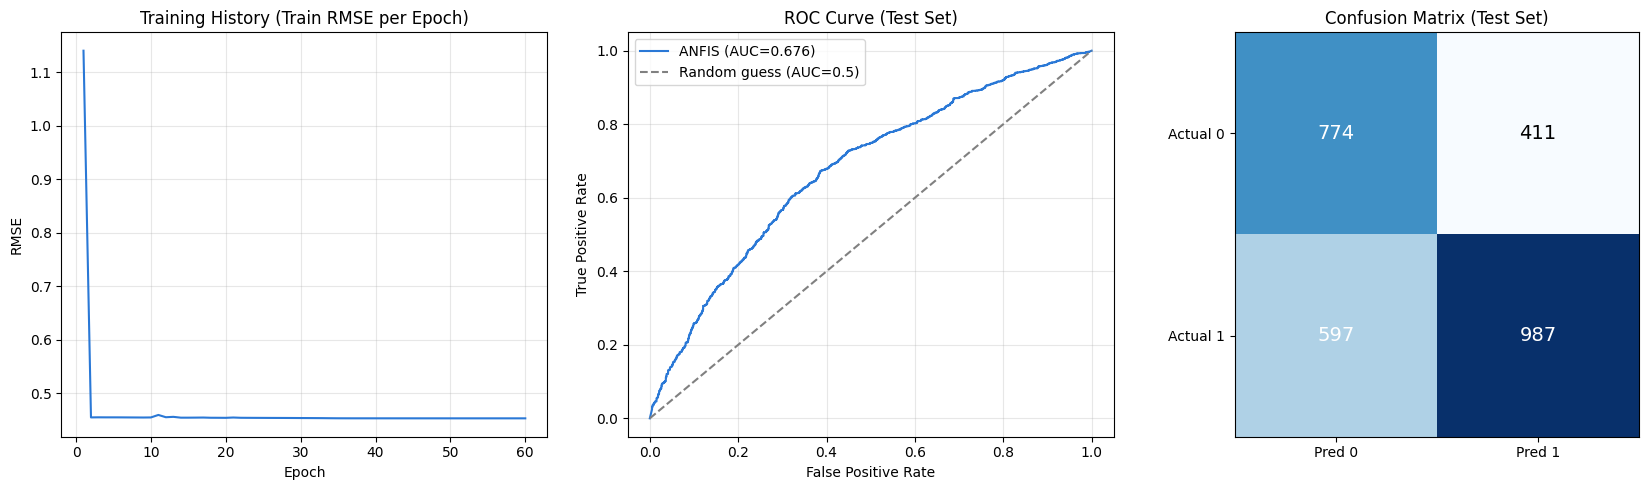

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
# ============================================================
# SECTION 24: RESULTS VISUALIZATION
# ============================================================

cm = confusion_matrix(y_test, pred_test)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].plot(range(1, len(history)+1), history, color="#2a78d6")
axes[0].set_title("Training History (Train RMSE per Epoch)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("RMSE")
axes[0].grid(alpha=0.3)

fpr_t, tpr_t, _ = roc_curve(y_test, score_test)
axes[1].plot(fpr_t, tpr_t, color="#2a78d6", label=f"ANFIS (AUC={auc_test:.3f})")
axes[1].plot([0, 1], [0, 1], "--", color="gray", label="Random guess (AUC=0.5)")
axes[1].set_title("ROC Curve (Test Set)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()
axes[1].grid(alpha=0.3)

im = axes[2].imshow(cm, cmap="Blues")
axes[2].set_title("Confusion Matrix (Test Set)")
axes[2].set_xticks([0, 1]); axes[2].set_xticklabels(["Pred 0", "Pred 1"])
axes[2].set_yticks([0, 1]); axes[2].set_yticklabels(["Actual 0", "Actual 1"])
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, str(cm[i, j]), ha="center", va="center",
                     color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=14)
plt.tight_layout()
plt.savefig("evaluation_anfis_6var.png", dpi=150)
plt.show()

try:
    files.download("evaluation_anfis_6var.png")
except Exception:
    pass

## Section 25: Manual Simulation Example

Example prediction for one Student-Problem pair baru (nilai X1-X6 mentah,
sebelum normalisasi).


In [33]:
import os, io, json, shutil, zipfile, itertools, subprocess
from pathlib import Path
from difflib import SequenceMatcher
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
)
try:
    import rarfile
    for _kandidat in ["unrar", "unrar-free"]:
        if shutil.which(_kandidat):
            rarfile.UNRAR_TOOL = _kandidat
            break
except ImportError:
    pass
try:
    from google.colab import files
except ImportError:
    pass
np.random.seed(42)

contoh_raw = np.array([[1.0, 3.83, 1.0, 42, 16, 0.78]])  # X1..X6
contoh_norm = (contoh_raw - x_min) / (x_max - x_min + 1e-12)
skor_contoh = model.predict(contoh_norm)[0]
pred_contoh = int(skor_contoh >= threshold)

print("Input  : X1=1.0, X2=3.83, X3=1.0, X4=42, X5=16, X6=0.78")
print(f"Skor prediksi (kecenderungan Label=1) : {skor_contoh:.4f}")
print(f"Ambang keputusan                      : {threshold:.4f}")
print(f"Prediksi Label                        : {pred_contoh} ({'berhasil efisien' if pred_contoh==1 else 'butuh scaffolding'})")

Input  : X1=1.0, X2=3.83, X3=1.0, X4=42, X5=16, X6=0.78
Skor prediksi (kecenderungan Label=1) : 0.2696
Ambang keputusan                      : 0.6164
Prediksi Label                        : 0 (butuh scaffolding)


## Section 26: Save & Download Results


In [36]:
# ============================================================
# SECTION 26: SAVE & DOWNLOAD RESULTS
# ============================================================

# Save the final dataset (X1-X6 + Label) for reproducibility
dataset.to_csv("dataset_anfis_6var.csv", index=False)

# Save per-row test predictions
hasil_prediksi_df = pd.DataFrame({
    "SubjectID": dataset.iloc[idx_test]["SubjectID"].values if "SubjectID" in dataset.columns else range(len(y_test)),
    "y_true": y_test,
    "score": score_test,
    "y_pred": pred_test,
})
hasil_prediksi_df.to_csv("hasil_prediksi_test_6var.csv", index=False)

print("Files generated in this session:")
file_list = [
    "dataset_anfis_6var.csv",
    "hasil_prediksi_test_6var.csv",
    "metrics_anfis_6var.json",
    "evaluation_anfis_6var.png",
]

for fn in file_list:
    if os.path.exists(fn):
        print(" - Downloading:", fn)
        files.download(fn)
    else:
        print(" - SKIPPED (not found, likely generated in a different session):", fn)

Files generated in this session:
 - Downloading: dataset_anfis_6var.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 - Downloading: hasil_prediksi_test_6var.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 - Downloading: evaluation_anfis_6var.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
### Methodological Notes

- **Unit of analysis:** Student-Problem pair (N ≈ 9,153 after filtering for pairs with ≥2 Compile events), not a per-student aggregate aserti demo 3-variabel.
- **Binary `Label` target** — evaluated with AUC/accuracy/precision/recall/F1, not RMSE/R² (that is for regression).
- **Decision threshold** is derived from the training data (Youden's J), not the default 0.5 — important since the Label distribution is imbalanced (~59%/41%).
- **X3 is redundant with X1** in the 2-attempt window scheme (already documented in `Analisis_Final_Variabel_CodeWorkout.md`) — tetap dipertahankan karena bermakna konseptual untuk rule-base, meski tumpang tindih secara statistik dengan X1.
- **Performance (AUC) in this from-scratch implementation may differ** from the reference figure (AUC 0.673, from a quick logistic regression result) karena perbedaan algoritma pembelajaran — laporkan performa yang benar-benar didapat of notebook ini, bukan angka referensi, konsisten dengan prinsip kejujuran performa yang sudah ditetapkan di seluruh dokumen disertasi.
